In [2]:
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter
import matplotlib.ticker as tkr
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [7]:
#load df
df_original = pd.read_csv('greece_listings.csv',low_memory=False)
df = df_original.copy()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   location_name      20000 non-null  object 
 1   location_region    20000 non-null  object 
 2   res_date           20000 non-null  object 
 3   res_type           20000 non-null  object 
 4   res_address        20000 non-null  object 
 5   res_price          20000 non-null  int64  
 6   res_price_sqr      19998 non-null  float64
 7   res_sqr            19999 non-null  float64
 8   construction_year  19214 non-null  float64
 9   levels             19992 non-null  object 
 10  bedrooms           18935 non-null  float64
 11  bathrooms          18214 non-null  float64
 12  deleted            20000 non-null  int64  
 13  deleted_at         16885 non-null  object 
 14  status             18195 non-null  object 
 15  energyclass        18186 non-null  object 
 16  auto_heating       200

In [9]:
df['deleted']

0        1
1        1
2        1
3        1
4        1
        ..
19995    1
19996    0
19997    0
19998    1
19999    1
Name: deleted, Length: 20000, dtype: int64

In [6]:
df_original.head()

,location_name,location_region,res_date,res_type,res_address,res_price,res_price_sqr,res_sqr,construction_year,levels,...,energyclass,auto_heating,solar,cooling,safe_door,gas,fireplace,furniture,student,parking
0,Παλαιό Φάληρο,Αττική,2021-06-18,Διαμέρισμα,"Παλαιό Φάληρο,Γήπεδα",89000,1618.0,55.0,1973.0,Υπερυψωμένο,...,Δ,1,0,1,1,0,0,0,0,NaN
1,Αχαρνές,Αττική,2022-03-30,Μεζονέτα,"Αχαρνές,Λαθέα",150000,1531.0,98.0,2010.0,4ος,...,Γ,0,0,0,0,0,1,0,0,Κλειστό parking
2,Παγκράτι,Αττική,2022-02-25,Διαμέρισμα,"Αθήνα,Παγκράτι",400000,3175.0,126.0,1990.0,3ος,...,Δ,1,0,1,1,0,1,0,0,NaN
3,Αθήνα,Αττική,2022-03-21,Διαμέρισμα,"Αθήνα,Άγιος Παντελεήμονας",80000,941.0,85.0,1957.0,5ος,...,Ζ,1,0,0,1,0,0,0,1,NaN
4,Ίλιον,Αττική,2022-01-11,Διαμέρισμα,"Αθήνα,Άγιος Ελευθέριος",100000,2083.0,48.0,1996.0,1ος,...,Δ,1,0,0,1,0,0,0,0,NaN


In [11]:
df['location_region'].value_counts()

location_region
Αττική         18813
Θεσσαλονίκη     1187
Name: count, dtype: int64

In [19]:
mean_price_by_region = df.groupby('location_region')['res_price'].mean().sort_values(ascending=False)
print(mean_price_by_region)

location_region
Αττική         377020.589167
Θεσσαλονίκη    209952.876158
Name: res_price, dtype: float64


In [20]:
df['location_region'].unique()

array(['Αττική', 'Θεσσαλονίκη'], dtype=object)

In [53]:
df_attica = df[df['location_region'] == 'Αττική'].copy()
df_thessaloniki = df[df['location_region'] == 'Θεσσαλονίκη'].copy()

In [65]:
df_attica = df_attica[df_attica['res_sqr'] <= 1000].copy()

1. Average price per location 

In [66]:
# use of count in order to know on what base we use mean

In [67]:
attica_location_stats = df_attica.groupby('location_name').agg(
    avg_price_per_sqr=('res_price_sqr', 'mean'),
    count=('location_region', 'count')
).reset_index()

attica_location_stats['avg_price_per_sqr'] = attica_location_stats['avg_price_per_sqr'].round(2)

attica_location_stats = attica_location_stats.sort_values('avg_price_per_sqr', ascending=[False])

print(attica_location_stats)

                 location_name  avg_price_per_sqr  count
12  Βάρη - Βούλα - Βουλιαγμένη            4801.61    996
16                     Γλυφάδα            4403.29    739
21      Ελληνικό - Αργυρούπολη            3780.72    208
2                       Άλιμος            3670.72    637
52            Φιλοθέη - Ψυχικό            3517.12    101
42               Παλαιό Φάληρο            3268.68    348
9                  Αργυρούπολη            3095.78    246
44                     Παπάγου            2999.20     35
56                    Χολαργός            2946.25    117
27                     Κηφισιά            2905.68     53
34                     Μαρούσι            2823.98    621
5               Αγία Παρασκευή            2781.74     72
54                    Χαλάνδρι            2765.90    785
23                   Ηλιούπολη            2756.22    312
13                   Βριλήσσια            2683.54     39
1              Άγιος Δημήτριος            2666.45    192
37                  Νέα Σμύρνη 

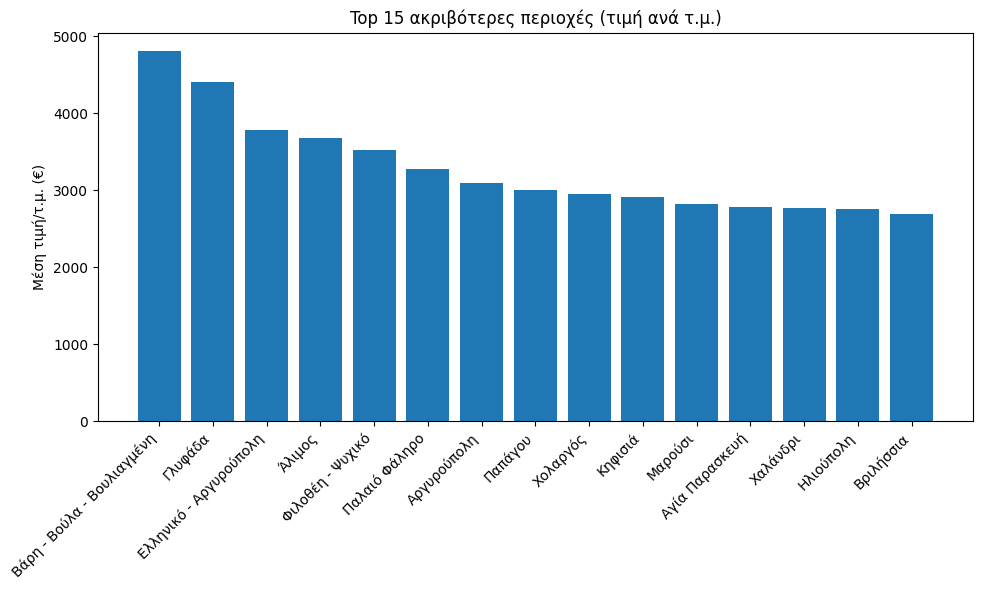

In [68]:
reliable = attica_location_stats[attica_location_stats['count'] >= 15]
top_price = reliable.sort_values('avg_price_per_sqr', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.bar(top_price['location_name'], top_price['avg_price_per_sqr'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Μέση τιμή/τ.μ. (€)')
plt.title('Top 15 ακριβότερες περιοχές (τιμή ανά τ.μ.)')
plt.tight_layout()
plt.show()

In [69]:
df_attica[df_attica['location_name'] == 'Παλαιό Φάληρο'].sort_values('res_sqr', ascending=False).head(5)



,location_name,location_region,res_date,res_type,res_address,res_price,res_price_sqr,res_sqr,construction_year,levels,...,energyclass,auto_heating,solar,cooling,safe_door,gas,fireplace,furniture,student,parking
4841,Παλαιό Φάληρο,Αττική,2021-07-14,Μονοκατοικία,"Άλιμος,Αμπελάκια",2000000,3333.0,600.0,1978.0,"Ισόγειο,1ος,2ος",...,Εκρεμμεί,1,0,0,0,0,1,0,0,NaN
11987,Παλαιό Φάληρο,Αττική,2020-11-28,Μονοκατοικία,"Άλιμος,Αμπελάκια",1500000,2500.0,600.0,1973.0,"Ισόγειο,1ος",...,Ε,1,0,0,0,0,1,0,0,NaN
17697,Παλαιό Φάληρο,Αττική,2022-03-16,Διαμέρισμα,"Παλαιό Φάληρο,Κέντρο",1100000,2292.0,480.0,1975.0,Ισόγειο,...,Ε,0,0,0,0,0,0,0,0,NaN
15851,Παλαιό Φάληρο,Αττική,2021-06-02,Μονοκατοικία,"Παλαιό Φάληρο,Αγιά Βαρβάρα",800000,1778.0,450.0,1955.0,"Ισόγειο,1ος",...,Εκρεμμεί,1,1,1,0,0,0,0,0,NaN
4546,Παλαιό Φάληρο,Αττική,2022-03-22,Μονοκατοικία,"Παλαιό Φάληρο,Πλατεία Ντάβαρη",1300000,3881.0,335.0,1990.0,"Ισόγειο,1ος,2ος",...,Γ,1,0,0,1,1,1,1,0,NaN


In [70]:
attica_location_sqr_stats = df_attica.groupby('location_name').agg(
    avg_sqr=('res_sqr', 'mean'),
    count=('location_region', 'count')
).reset_index()

attica_location_sqr_stats['avg_sqr'] = attica_location_sqr_stats['avg_sqr'].round(2)
attica_location_sqr_stats = attica_location_sqr_stats.sort_values('avg_sqr', ascending=False)
print(attica_location_sqr_stats)

                 location_name  avg_sqr  count
19                    Διόνυσος   310.54    444
46                     Πεντέλη   303.35     68
49              Ραφήνα Πικέρμι   255.25    155
29                      Κρωπία   242.39    215
27                     Κηφισιά   229.43     53
30                  Λαυρεωτική   216.53    217
41                     Παιανία   216.30     43
11                     Αχαρνές   212.10   1333
12  Βάρη - Βούλα - Βουλιαγμένη   208.48    996
52            Φιλοθέη - Ψυχικό   200.16    101
13                   Βριλήσσια   198.92     39
4                       Αίγινα   190.72     50
43                     Παλλήνη   190.22     87
53                        Φυλή   183.24     17
32           Μάνδρα - Ειδυλλία   181.42     33
51                       Σπάτα   177.28    153
31             Λυκόβρυση Πεύκη   168.40     20
33                      Μέγαρα   162.55     53
55                     Χαϊδάρι   161.72     74
16                     Γλυφάδα   159.83    739
21      Ελλην

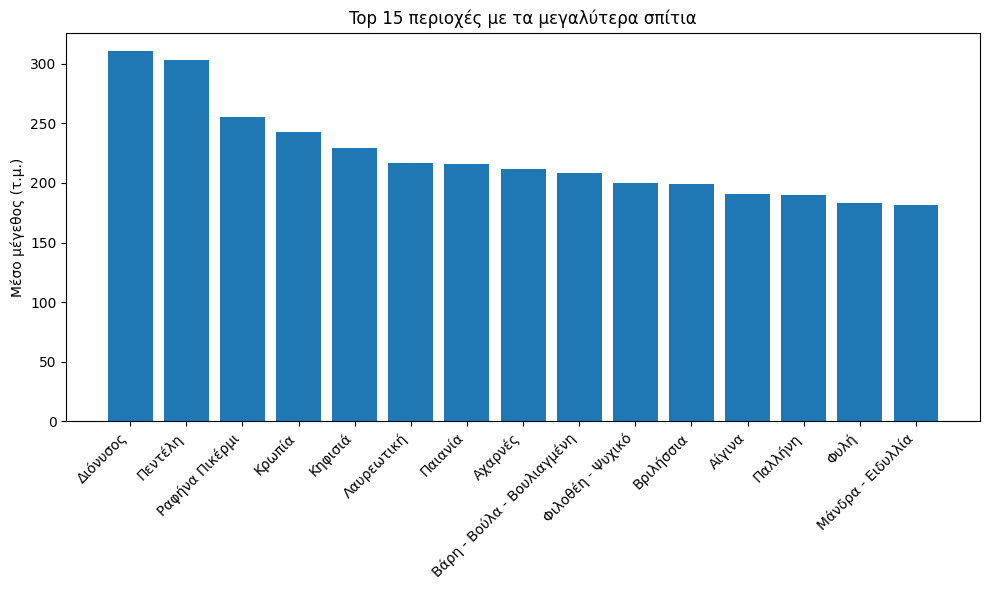

In [71]:
reliable_sqr = attica_location_sqr_stats[attica_location_sqr_stats['count'] >= 15]
top_size = reliable_sqr.sort_values('avg_sqr', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.bar(top_size['location_name'], top_size['avg_sqr'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Μέσο μέγεθος (τ.μ.)')
plt.title('Top 15 περιοχές με τα μεγαλύτερα σπίτια')
plt.tight_layout()
plt.show()

In [72]:
df_attica['construction_year'].value_counts()

construction_year
2022.0    1384
2021.0    1231
1970.0    1127
1980.0     867
1975.0     735
          ... 
1907.0       1
1911.0       1
1948.0       1
1931.0       1
1914.0       1
Name: count, Length: 112, dtype: int64

In [73]:
min_year = int(df_attica['construction_year'].min())
max_year = int(df_attica['construction_year'].max())
print(min_year, max_year)

1900 2022


In [74]:
bin_edges = list(range(1900, 2026, 5))
labels = [f"{bin_edges[i]}-{bin_edges[i+1]-1}" for i in range(len(bin_edges) - 1)]

df_attica['year_bucket'] = pd.cut(
    df_attica['construction_year'],
    bins=bin_edges,
    right=False,
    labels=labels
)

df_attica['year_bucket'].value_counts().sort_index()

year_bucket
1900-1904      11
1905-1909       6
1910-1914       8
1915-1919       2
1920-1924      35
1925-1929      23
1930-1934      55
1935-1939      70
1940-1944      38
1945-1949      20
1950-1954     187
1955-1959     295
1960-1964     921
1965-1969    1231
1970-1974    2272
1975-1979    1753
1980-1984    1458
1985-1989     675
1990-1994     750
1995-1999     643
2000-2004    1122
2005-2009    1839
2010-2014    1055
2015-2019     368
2020-2024    3090
Name: count, dtype: int64

In [75]:
df_attica.head()

,location_name,location_region,res_date,res_type,res_address,res_price,res_price_sqr,res_sqr,construction_year,levels,...,auto_heating,solar,cooling,safe_door,gas,fireplace,furniture,student,parking,year_bucket
0,Παλαιό Φάληρο,Αττική,2021-06-18,Διαμέρισμα,"Παλαιό Φάληρο,Γήπεδα",89000,1618.0,55.0,1973.0,Υπερυψωμένο,...,1,0,1,1,0,0,0,0,NaN,1970-1974
1,Αχαρνές,Αττική,2022-03-30,Μεζονέτα,"Αχαρνές,Λαθέα",150000,1531.0,98.0,2010.0,4ος,...,0,0,0,0,0,1,0,0,Κλειστό parking,2010-2014
2,Παγκράτι,Αττική,2022-02-25,Διαμέρισμα,"Αθήνα,Παγκράτι",400000,3175.0,126.0,1990.0,3ος,...,1,0,1,1,0,1,0,0,NaN,1990-1994
3,Αθήνα,Αττική,2022-03-21,Διαμέρισμα,"Αθήνα,Άγιος Παντελεήμονας",80000,941.0,85.0,1957.0,5ος,...,1,0,0,1,0,0,0,1,NaN,1955-1959
4,Ίλιον,Αττική,2022-01-11,Διαμέρισμα,"Αθήνα,Άγιος Ελευθέριος",100000,2083.0,48.0,1996.0,1ος,...,1,0,0,1,0,0,0,0,NaN,1995-1999


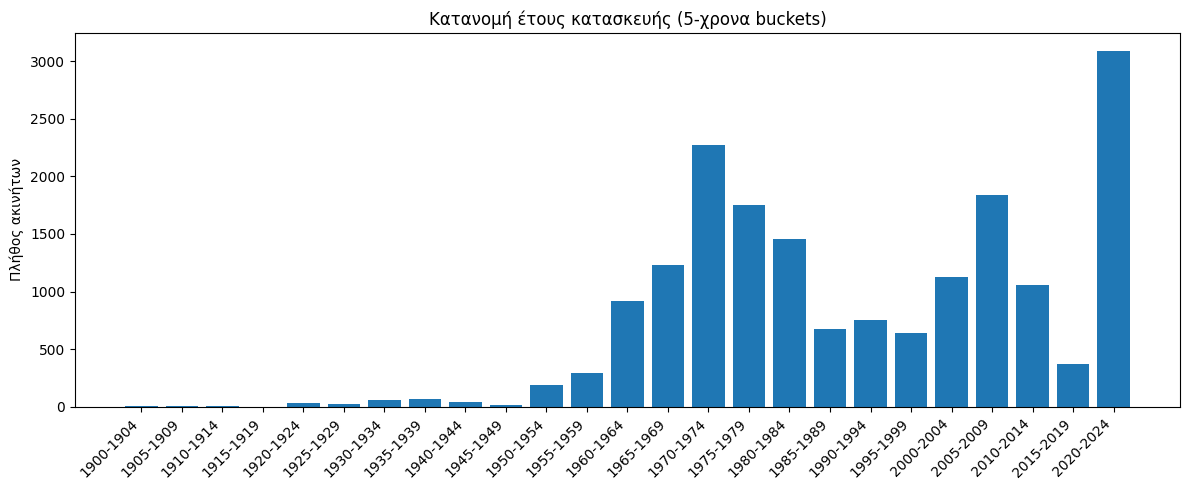

In [76]:
year_counts = df_attica['year_bucket'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(year_counts.index.astype(str), year_counts.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Πλήθος ακινήτων')
plt.title('Κατανομή έτους κατασκευής (5-χρονα buckets)')
plt.tight_layout()
plt.show()

Πλήθος ακινήτων ανά περιοχή

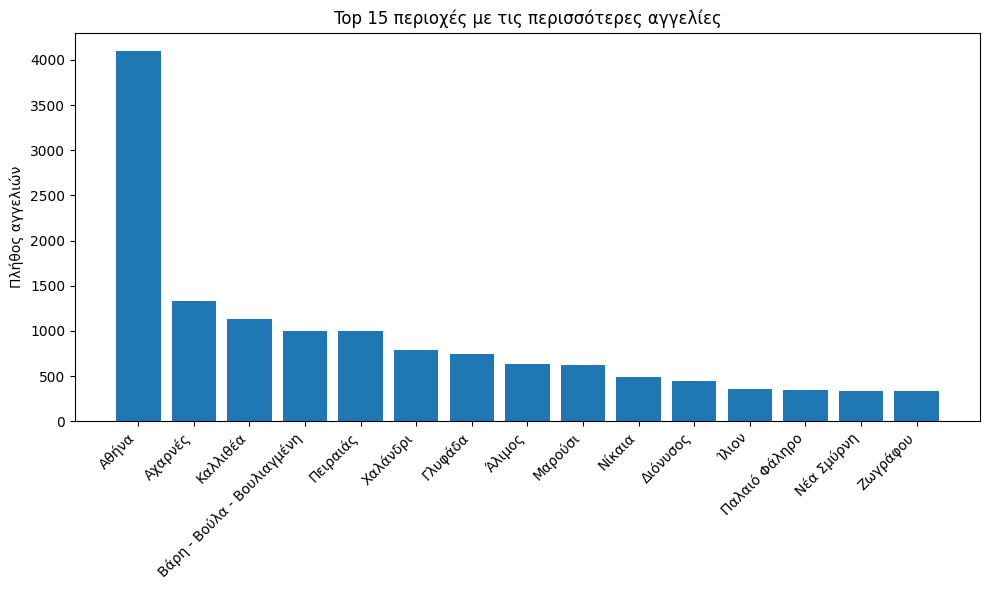

In [77]:
location_counts = df_attica['location_name'].value_counts().head(15)

plt.figure(figsize=(10, 6))
plt.bar(location_counts.index, location_counts.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Πλήθος αγγελιών')
plt.title('Top 15 περιοχές με τις περισσότερες αγγελίες')
plt.tight_layout()
plt.show()

τύπος σπιτιού

In [78]:
#Πλήθος ανά τύπο:
df_attica['res_type'].value_counts()

res_type
Διαμέρισμα      13007
Μονοκατοικία     2403
Μεζονέτα         2351
Κτίριο            798
Οικία             134
Name: count, dtype: int64

In [79]:
#μέση τιμή/τ.μ. ανά τύπο
avg_price_sqr_by_type = df_attica.groupby('res_type')['res_price_sqr'].mean().round(2).sort_values(ascending=False)
print(avg_price_sqr_by_type)

res_type
Μεζονέτα        3078.19
Μονοκατοικία    2477.68
Διαμέρισμα      2410.52
Οικία           1772.06
Κτίριο          1727.58
Name: res_price_sqr, dtype: float64


In [80]:
#μ έσο μέγεθος ανά τύπ
avg_sqr_by_type = df_attica.groupby('res_type')['res_sqr'].mean().round(2).sort_values(ascending=False)
print(avg_sqr_by_type)

res_type
Κτίριο          434.16
Οικία           278.05
Μονοκατοικία    248.46
Μεζονέτα        203.15
Διαμέρισμα       90.42
Name: res_sqr, dtype: float64


In [87]:
location_year_price = df_attica.groupby('location_name').agg(
    avg_construction_year=('construction_year', 'mean'),
    avg_price_per_sqr=('res_price_sqr', 'mean'),
    count=('location_region', 'count')
).reset_index()

location_year_price['avg_construction_year'] = location_year_price['avg_construction_year'].round(0)
location_year_price['avg_price_per_sqr'] = location_year_price['avg_price_per_sqr'].round(2)

reliable_yp = location_year_price[location_year_price['count'] >= 15].copy()

print(reliable_yp.sort_values('avg_price_per_sqr', ascending=False).head(15))

                 location_name  avg_construction_year  avg_price_per_sqr  \
12  Βάρη - Βούλα - Βουλιαγμένη                 2001.0            4801.61   
16                     Γλυφάδα                 2003.0            4403.29   
21      Ελληνικό - Αργυρούπολη                 2003.0            3780.72   
2                       Άλιμος                 2007.0            3670.72   
52            Φιλοθέη - Ψυχικό                 1984.0            3517.12   
42               Παλαιό Φάληρο                 1998.0            3268.68   
9                  Αργυρούπολη                 2000.0            3095.78   
44                     Παπάγου                 1993.0            2999.20   
56                    Χολαργός                 1992.0            2946.25   
27                     Κηφισιά                 2000.0            2905.68   
34                     Μαρούσι                 1997.0            2823.98   
5               Αγία Παρασκευή                 1994.0            2781.74   
54          

In [89]:
newest_areas = reliable_yp.sort_values('avg_construction_year', ascending=False)
print(newest_areas.head(10))

                 location_name  avg_construction_year  avg_price_per_sqr  \
2                       Άλιμος                 2007.0            3670.72   
13                   Βριλήσσια                 2004.0            2683.54   
16                     Γλυφάδα                 2003.0            4403.29   
21      Ελληνικό - Αργυρούπολη                 2003.0            3780.72   
23                   Ηλιούπολη                 2003.0            2756.22   
12  Βάρη - Βούλα - Βουλιαγμένη                 2001.0            4801.61   
19                    Διόνυσος                 2001.0            2194.03   
43                     Παλλήνη                 2001.0            2151.34   
9                  Αργυρούπολη                 2000.0            3095.78   
49              Ραφήνα Πικέρμι                 2000.0            1981.46   

    count  
2     637  
13     39  
16    739  
21    208  
23    312  
12    996  
19    444  
43     87  
9     246  
49    155  


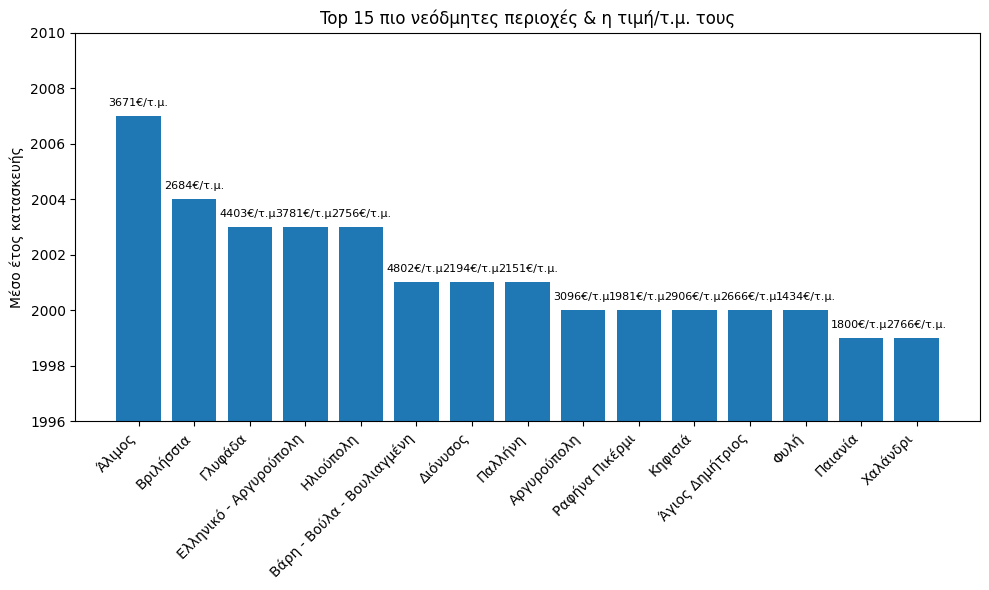

In [90]:
top_newest = newest_areas.head(15)

plt.figure(figsize=(10, 6))
bars = plt.bar(top_newest['location_name'], top_newest['avg_construction_year'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Μέσο έτος κατασκευής')
plt.title('Top 15 πιο νεόδμητες περιοχές & η τιμή/τ.μ. τους')

# Σημαντικό: ρυθμίζουμε το y-axis ώστε να φαίνονται οι διαφορές
plt.ylim(top_newest['avg_construction_year'].min() - 3, top_newest['avg_construction_year'].max() + 3)

# Προσθήκη της τιμής/τ.μ. πάνω σε κάθε μπάρα
for bar, price in zip(bars, top_newest['avg_price_per_sqr']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{price:.0f}€/τ.μ.', ha='center', va='bottom', fontsize=8, rotation=0)

plt.tight_layout()
plt.savefig('newest_areas_with_price.png', dpi=150, bbox_inches='tight')
plt.show()